# Root Cause Analysis (RCA) — Clasificador Multiclase

**AMIA V3 — Notebook de desarrollo**

El modelo V2 responde: *¿va a fallar esta máquina en las próximas 24 h?*  
El modelo RCA responde: *¿qué la está causando?*

El agente llama a RCA **solo cuando** V2 detecta riesgo alto — por eso entrenamos
únicamente sobre periodos de degradación activa, no sobre operación normal.

## El problema: diagnóstico multiclase

| Modo de fallo | Firma de sensores | Máquinas afectadas |
|---|---|---|
| `bearing_wear` | Vibración alta, tendencia creciente | Todas |
| `overheating` | Temperatura elevada (bearing + motor) | Todas |
| `cavitation` | Presión irregular, vibración moderada | Solo centrifugal_pump |
| `misalignment` | Vibración + RPM irregular | pump, induction_motor |
| `electrical_failure` | Desequilibrio de corriente entre fases | Todas |

### Decisiones de diseño
- **5 clases**, no 6: la fila `failure_mode='failure'` (34 rows) es el instante exacto del colapso —
  no tiene patrón de degradación útil, la descartamos.
- **Mismo feature engineering que V2**: los patrones de degradación son visibles en rolling stats,
  tendencias y features cross-sensor. No hay que re-inventar la rueda.
- **`machine_type` como feature**: `cavitation` solo ocurre en bombas — el tipo de máquina es
  información crítica para el clasificador.
- **`sample_weight` balanceado**: `bearing_wear` tiene 9x más datos que `electrical_failure`.
  Sin balanceo, el modelo ignoraría las clases raras.

## Paso 0: Imports y configuración de rutas

In [43]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Rutas ─────────────────────────────────────────────────────────────────
# Sube directorios desde ml/amia_ml/notebooks/ hasta encontrar data/synthetic/
_p = Path().resolve()
REPO_ROOT = _p
for _ in range(6):
    if (REPO_ROOT / 'data' / 'synthetic').exists():
        break
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH  = REPO_ROOT / 'data/synthetic/sensor_readings.parquet'
MLFLOW_URI = f'sqlite:///{REPO_ROOT / "mlflow.db"}'

print(f'REPO_ROOT : {REPO_ROOT}')
print(f'DATA_PATH : {DATA_PATH.exists()=}')
print(f'MLFLOW_URI: {MLFLOW_URI}')

REPO_ROOT : /Users/juanmanuel/dev/autonomous-maintenance-intelligence-agent
DATA_PATH : DATA_PATH.exists()=True
MLFLOW_URI: sqlite:////Users/juanmanuel/dev/autonomous-maintenance-intelligence-agent/mlflow.db


---
## Paso 1: EDA — Entender los datos

Antes de entrenar cualquier modelo, respondemos tres preguntas:
1. ¿Cómo está distribuida la clase?
2. ¿Qué sensores discriminan mejor cada modo de fallo?
3. ¿Hay clases con tan pocos datos que serán difíciles de aprender?

In [44]:
df_raw = pd.read_parquet(DATA_PATH)
df_raw = df_raw.sort_values(['machine_id', 'timestamp']).reset_index(drop=True)

print(f'Shape total: {df_raw.shape}')
print('\nfailure_mode (todos los datos):')
print(df_raw['failure_mode'].value_counts())

# Filas en degradación activa (las que usaremos para RCA)
df_degrad = df_raw[
    (df_raw['degradation_fraction'] > 0) &
    (df_raw['failure_mode'] != 'failure')   # drop evento final (34 rows)
].copy()

print(f'\nFilas de degradación (training pool): {len(df_degrad):,}')
print(f'Proporción del dataset: {len(df_degrad)/len(df_raw):.1%}')

Shape total: (43800, 16)

failure_mode (todos los datos):
failure_mode
normal                39417
bearing_wear           2229
overheating            1222
cavitation              327
misalignment            319
electrical_failure      252
failure                  34
Name: count, dtype: int64

Filas de degradación (training pool): 4,315
Proporción del dataset: 9.9%


### 1.1 Distribución de clases

**Qué buscamos**: clases muy pequeñas necesitarán peso extra. Una ratio >10:1 es un desafío real.

Distribución de clases (degradation rows):
failure_mode
bearing_wear          2220
overheating           1212
cavitation             322
misalignment           314
electrical_failure     247

Ratio max/min: 9.0:1


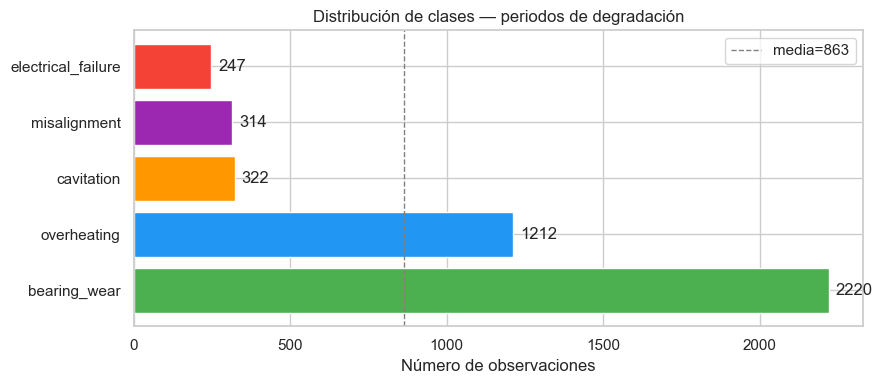

In [45]:
counts = df_degrad['failure_mode'].value_counts()
print('Distribución de clases (degradation rows):')
print(counts.to_string())
print(f'\nRatio max/min: {counts.iloc[0]/counts.iloc[-1]:.1f}:1')

fig, ax = plt.subplots(figsize=(9, 4))
palette = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336']
bars = ax.barh(counts.index, counts.values, color=palette)
ax.bar_label(bars, padding=5, fmt='%d')
ax.set_xlabel('Número de observaciones')
ax.set_title('Distribución de clases — periodos de degradación')
ax.axvline(counts.mean(), color='gray', ls='--', lw=1, label=f'media={counts.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

### 1.2 Huella de sensores por modo de fallo

Normalizamos cada sensor (z-score global) y calculamos la media por clase.
Esto revela cuáles sensores son más discriminativos.

**Interpretación del heatmap**:
- Rojo = valor alto respecto a la media global
- Azul = valor bajo
- Una clase con una fila mayormente gris no tiene firma clara → será difícil de clasificar

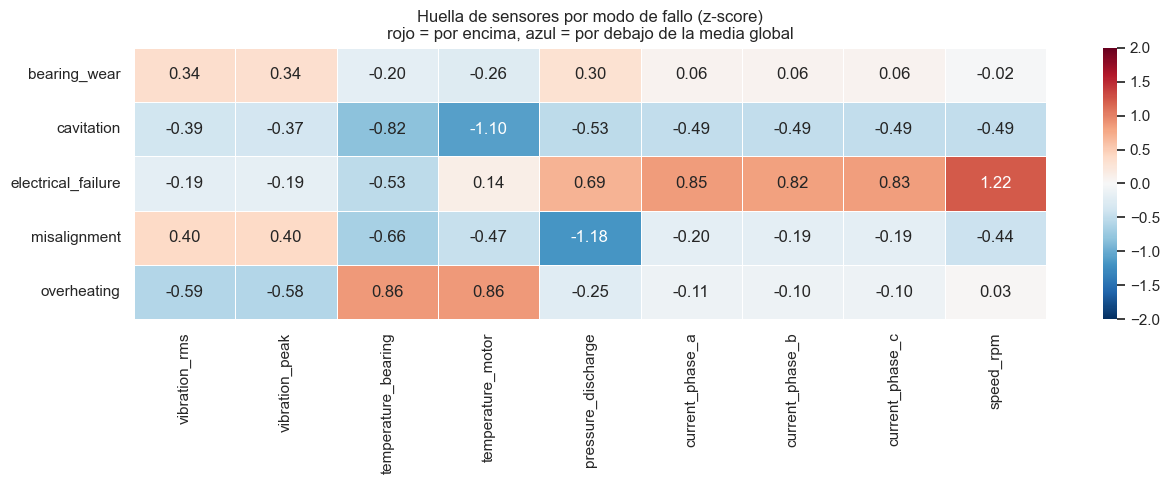

Observaciones clave:
  bearing_wear     → vibración alta
  overheating      → temperatura alta (bearing + motor)
  electrical_fail. → corrientes elevadas (más carga eléctrica)
  cavitation       → presión baja / irregular
  misalignment     → vibración alta + RPM desviado


In [46]:
SENSORS_RAW = [
    'vibration_rms', 'vibration_peak',
    'temperature_bearing', 'temperature_motor',
    'pressure_discharge',
    'current_phase_a', 'current_phase_b', 'current_phase_c',
    'speed_rpm',
]

df_z = df_degrad.copy()
for s in SENSORS_RAW:
    mu, sigma = df_z[s].mean(), df_z[s].std()
    df_z[f'z_{s}'] = (df_z[s] - mu) / (sigma + 1e-8)

z_cols = [f'z_{s}' for s in SENSORS_RAW]
heatmap_data = df_z.groupby('failure_mode')[z_cols].mean()
heatmap_data.columns = SENSORS_RAW

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-2, vmax=2,
    ax=ax, linewidths=0.5,
)
ax.set_title(
    'Huella de sensores por modo de fallo (z-score)\n'
    'rojo = por encima, azul = por debajo de la media global'
)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('Observaciones clave:')
print('  bearing_wear     → vibración alta')
print('  overheating      → temperatura alta (bearing + motor)')
print('  electrical_fail. → corrientes elevadas (más carga eléctrica)')
print('  cavitation       → presión baja / irregular')
print('  misalignment     → vibración alta + RPM desviado')

### 1.3 Boxplots de las features más discriminativas

Confirmamos visualmente las firmas clave antes de entrenar.

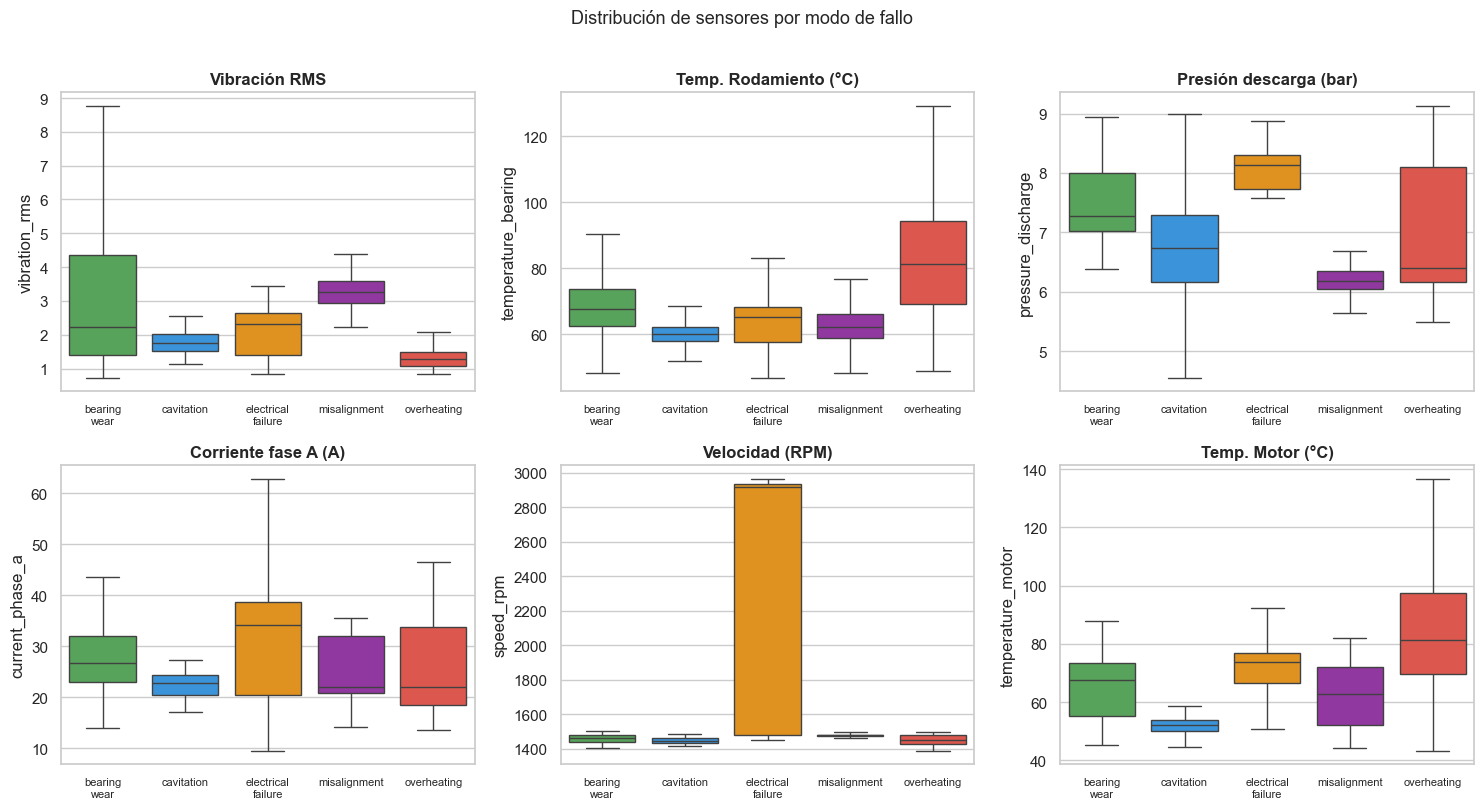

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features_to_plot = [
    ('vibration_rms',       'Vibración RMS'),
    ('temperature_bearing', 'Temp. Rodamiento (°C)'),
    ('pressure_discharge',  'Presión descarga (bar)'),
    ('current_phase_a',     'Corriente fase A (A)'),
    ('speed_rpm',           'Velocidad (RPM)'),
    ('temperature_motor',   'Temp. Motor (°C)'),
]
order = ['bearing_wear', 'cavitation', 'electrical_failure', 'misalignment', 'overheating']

for ax, (feat, title) in zip(axes.flat, features_to_plot):
    sns.boxplot(
        data=df_degrad, x='failure_mode', y=feat,
        order=order, ax=ax,
        palette=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336'],
        showfliers=False,
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels([o.replace('_', '\n') for o in order], fontsize=8)

plt.suptitle('Distribución de sensores por modo de fallo', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Paso 2: Feature Engineering

Reutilizamos **el mismo pipeline que V2** (rolling stats, tendencias, deltas, cross-sensor).

**¿Por qué el mismo pipeline?** Porque el patrón de degradación no es visible en un
solo instante — está codificado en la *trayectoria temporal*: una vibración que lleva
8 horas subiendo es muy diferente a una vibración que acaba de subir.

**Trampa importante**: debemos calcular las features sobre **todos** los datos (incluyendo
operación normal) y filtrar a degradación después. Si filtramos antes, las ventanas
rolling de 8 h / 24 h quedarían truncadas y las features serían basura.

In [48]:
SENSORS = [
    'vibration_rms', 'vibration_peak', 'temperature_bearing',
    'temperature_motor', 'pressure_discharge', 'speed_rpm'
]
WINDOWS = {'8h': 8, '24h': 24}
BASELINE_HOURS = 168  # primeras 7 días = referencia de salud por máquina

def add_rolling_stats(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for sensor in SENSORS:
        grp = out.groupby('machine_id')[sensor]
        for label, w in WINDOWS.items():
            out[f'{sensor}_mean_{label}'] = grp.transform(lambda x: x.rolling(w, min_periods=2).mean())
            out[f'{sensor}_std_{label}']  = grp.transform(lambda x: x.rolling(w, min_periods=2).std())
            out[f'{sensor}_max_{label}']  = grp.transform(lambda x: x.rolling(w, min_periods=2).max())
            out[f'{sensor}_kurt_{label}'] = grp.transform(lambda x: x.rolling(w, min_periods=4).kurt())
    return out


def _linear_slope(arr: np.ndarray) -> float:
    mask = ~np.isnan(arr)
    if mask.sum() < 2:
        return np.nan
    x = np.arange(len(arr))
    return float(np.polyfit(x[mask], arr[mask], 1)[0])


def add_trend_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for sensor in SENSORS:
        grp = out.groupby('machine_id')[sensor]
        for label, w in WINDOWS.items():
            out[f'{sensor}_slope_{label}'] = grp.transform(
                lambda x: x.rolling(w, min_periods=2).apply(_linear_slope, raw=True)
            )
    return out


def add_delta_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for sensor in SENSORS:
        grp = out.groupby('machine_id')[sensor]
        out[f'{sensor}_delta_1h']  = grp.transform(lambda x: x.diff(1))
        out[f'{sensor}_delta_8h']  = grp.transform(lambda x: x.diff(8))
        out[f'{sensor}_delta_24h'] = grp.transform(lambda x: x.diff(24))
        out[f'{sensor}_accel']     = grp.transform(lambda x: x.diff(1).diff(1))
    return out


def add_cross_sensor_features(df: pd.DataFrame) -> pd.DataFrame:
    """Features que combinan múltiples sensores — clave para electrical_failure."""
    out = df.copy()
    # Desequilibrio de corriente entre fases → firma de fallo eléctrico
    out['current_imbalance']    = out[['current_phase_a', 'current_phase_b', 'current_phase_c']].std(axis=1)
    # Temperatura por RPM → detecta sobrecalentamiento a bajo régimen
    out['temp_per_rpm']         = out['temperature_bearing'] / out['speed_rpm'].replace(0, np.nan)
    # Estrés vibro-térmico → cuando vibración Y temperatura suben juntos
    out['vibro_thermal_stress'] = out['vibration_rms'] * out['temperature_bearing']
    out['temp_ratio']           = out['temperature_bearing'] / out['temperature_motor'].replace(0, np.nan)
    out['current_mean']         = out[['current_phase_a', 'current_phase_b', 'current_phase_c']].mean(axis=1)
    return out


def add_baseline_normalization(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza cada sensor contra las primeras 7 días de operación sana de cada máquina."""
    out = df.copy()
    for sensor in SENSORS:
        baseline = out.groupby('machine_id')[sensor].transform(
            lambda x: x.iloc[:BASELINE_HOURS].mean()
        )
        out[f'{sensor}_vs_baseline'] = out[sensor] - baseline
    return out


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    print('1/4  Rolling stats (mean/std/max/kurt × 8h, 24h)...')
    df = add_rolling_stats(df)
    print('2/4  Tendencias (pendiente lineal × 8h, 24h)...')
    df = add_trend_features(df)
    print('3/4  Deltas (1h / 8h / 24h / aceleración)...')
    df = add_delta_features(df)
    print('4/4  Cross-sensor + normalización baseline...')
    df = add_cross_sensor_features(df)
    df = add_baseline_normalization(df)
    print(f'     Shape: {df.shape}')
    return df


print('Funciones definidas. Ejecutar la siguiente celda para construir features...')

Funciones definidas. Ejecutar la siguiente celda para construir features...


In [49]:
# Esto tarda ~2-3 min en la primera ejecución (transform sobre 43k filas × 6 sensores)
df_feat = build_features(df_raw.copy())

# Encoding de machine_type
MACHINE_TYPE_MAP = {'compressor': 0, 'induction_motor': 1, 'centrifugal_pump': 2}
df_feat['machine_type_enc'] = df_feat['machine_type'].map(MACHINE_TYPE_MAP)

print(f'\nFeatures totales: {df_feat.shape[1]}')
print(f'Ejemplo de columnas nuevas: {[c for c in df_feat.columns if "_mean_" in c][:4]}')

1/4  Rolling stats (mean/std/max/kurt × 8h, 24h)...
2/4  Tendencias (pendiente lineal × 8h, 24h)...
3/4  Deltas (1h / 8h / 24h / aceleración)...
4/4  Cross-sensor + normalización baseline...
     Shape: (43800, 111)

Features totales: 112
Ejemplo de columnas nuevas: ['vibration_rms_mean_8h', 'vibration_rms_mean_24h', 'vibration_peak_mean_8h', 'vibration_peak_mean_24h']


---
## Paso 3: Preparar el target y el split temporal

### Target multiclase
Codifica los 5 modos de fallo como enteros (0-4). XGBoost necesita enteros.

### Split temporal (no aleatorio)
Usa la misma fecha de corte que V2: `2024-11-01`.

**¿Por qué temporal y no random?** Porque con un split aleatorio el modelo
vería datos de la misma máquina en train Y test — hay fuga de información temporal.
El split temporal simula cómo se comportará el modelo en producción (datos futuros).

In [50]:
CLASSES = sorted(['bearing_wear', 'cavitation', 'electrical_failure', 'misalignment', 'overheating'])
CLASS_MAP     = {c: i for i, c in enumerate(CLASSES)}
INV_CLASS_MAP = {v: k for k, v in CLASS_MAP.items()}

print('Mapping de clases:')
for cls, idx in CLASS_MAP.items():
    print(f'  {idx} → {cls}')

# Columnas que NO van como feature
LEAKAGE = ['failure_mode', 'is_failure', 'degradation_fraction', 'rul_hours', 'rca_label']
META    = ['timestamp', 'machine_id', 'machine_type']

# Añadir target
df_feat['rca_label'] = df_feat['failure_mode'].map(CLASS_MAP)  # NaN para 'normal' y 'failure'

# Filtrar solo filas con label válido
df_rca = df_feat[df_feat['rca_label'].notna()].copy()
df_rca['rca_label'] = df_rca['rca_label'].astype(int)

print(f'\nFilas de entrenamiento: {len(df_rca):,} (de {len(df_feat):,} totales)')
print('\nDistribución:')
for cls, idx in CLASS_MAP.items():
    n = (df_rca['rca_label'] == idx).sum()
    print(f'  {idx} — {cls:<22} {n:>5} ({n/len(df_rca):.1%})')

Mapping de clases:
  0 → bearing_wear
  1 → cavitation
  2 → electrical_failure
  3 → misalignment
  4 → overheating

Filas de entrenamiento: 4,349 (de 43,800 totales)

Distribución:
  0 — bearing_wear            2229 (51.3%)
  1 — cavitation               327 (7.5%)
  2 — electrical_failure       252 (5.8%)
  3 — misalignment             319 (7.3%)
  4 — overheating             1222 (28.1%)


In [51]:
SPLIT_DATE = pd.Timestamp('2024-11-01')

feature_cols = [c for c in df_rca.columns if c not in LEAKAGE + META]
print(f'Número de features: {len(feature_cols)}')

train_mask = df_rca['timestamp'] < SPLIT_DATE
test_mask  = df_rca['timestamp'] >= SPLIT_DATE

X_train = df_rca.loc[train_mask, feature_cols]
X_test  = df_rca.loc[test_mask,  feature_cols]
y_train = df_rca.loc[train_mask, 'rca_label']
y_test  = df_rca.loc[test_mask,  'rca_label']

print(f'\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}')

print('\nDistribución train / test:')
print(f'{"Clase":<22} {"Train":>8} {"Test":>8}')
print('-' * 40)
for cls, idx in CLASS_MAP.items():
    n_tr = (y_train == idx).sum()
    n_te = (y_test  == idx).sum()
    print(f'{cls:<22} {n_tr:>8} {n_te:>8}')

# Verificar que no hay timestamp del test en train
assert df_rca.loc[train_mask, 'timestamp'].max() < df_rca.loc[test_mask, 'timestamp'].min()
print('\n✓ Split temporal verificado — sin leakage')

Número de features: 105

Train: 3,936  |  Test: 413

Distribución train / test:
Clase                     Train     Test
----------------------------------------
bearing_wear               2017      212
cavitation                  240       87
electrical_failure          212       40
misalignment                319        0
overheating                1148       74

✓ Split temporal verificado — sin leakage


---
## Paso 4: Balanceo de clases con `sample_weight`

XGBoost multiclase **no tiene** `scale_pos_weight` (eso es solo para binario).
La solución es `sample_weight`: cada ejemplo recibe un peso inversamente proporcional
a la frecuencia de su clase.

**Efecto matemático**: el gradiente de una muestra de una clase rara 'pesa' más en la
actualización del árbol — el modelo aprende a no ignorarla.

Usamos `class_weight='balanced'` de sklearn, que calcula:
```
w_i = n_total / (n_clases × n_muestras_clase_i)
```

In [52]:
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASSES)),
    y=y_train.values,
)
weight_map   = dict(enumerate(class_weights_arr))
train_weights = y_train.map(weight_map).values

print('Pesos por clase:')
print(f'{"Clase":<22} {"N train":>8} {"Peso":>8}')
print('-' * 40)
for cls, idx in CLASS_MAP.items():
    n = (y_train == idx).sum()
    print(f'{cls:<22} {n:>8} {weight_map[idx]:>8.2f}')

print(f'\nMáx/mín ratio de pesos: {max(class_weights_arr)/min(class_weights_arr):.1f}x')

Pesos por clase:
Clase                   N train     Peso
----------------------------------------
bearing_wear               2017     0.39
cavitation                  240     3.28
electrical_failure          212     3.71
misalignment                319     2.47
overheating                1148     0.69

Máx/mín ratio de pesos: 9.5x


---
## Paso 5: Entrenar XGBoost multiclase

### Parámetros clave vs V2
| Parámetro | V2 (binario) | V3 RCA (multiclase) | Por qué cambia |
|---|---|---|---|
| `objective` | `binary:logistic` | `multi:softprob` | 5 clases, no 2 |
| `num_class` | — | `5` | obligatorio con softprob |
| `eval_metric` | `logloss` | `mlogloss` | log-loss multiclase |
| `scale_pos_weight` | `21` | — | no aplica a multiclase |
| `sample_weight` | — | `balanced` | balanceo de clases |
| `max_depth` | `5` | `4` | menos profundidad → menos overfitting con clases pequeñas |

`multi:softprob` devuelve un vector de probabilidades por clase (vs `softmax` que da solo la clase).
Necesitamos las probabilidades para la explicación del agente.

In [53]:
HPARAMS = {
    'n_estimators':      500,
    'max_depth':         4,
    'learning_rate':     0.05,
    'subsample':         0.8,
    'colsample_bytree':  0.7,
    'min_child_weight':  3,
    'gamma':             0.3,
    'reg_lambda':        2.0,
    'reg_alpha':         0.5,
    'objective':         'multi:softprob',
    'num_class':         len(CLASSES),
    'eval_metric':       'mlogloss',
    'early_stopping_rounds': 30,
    'random_state':      42,
    'n_jobs':            -1,
    'verbosity':         0,
}

model = xgb.XGBClassifier(
    **{k: v for k, v in HPARAMS.items() if k != 'early_stopping_rounds'},
    early_stopping_rounds=HPARAMS['early_stopping_rounds'],
)

model.fit(
    X_train, y_train,
    sample_weight=train_weights,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

print(f'\nMejor iteración: {model.best_iteration}')
print(f'Mejor mlogloss:  {model.best_score:.4f}')

[0]	validation_0-mlogloss:1.54348
[50]	validation_0-mlogloss:0.61616
[100]	validation_0-mlogloss:0.48719
[150]	validation_0-mlogloss:0.45144
[200]	validation_0-mlogloss:0.44667
[219]	validation_0-mlogloss:0.44730

Mejor iteración: 189
Mejor mlogloss:  0.4461


---
## Paso 6: Evaluación del modelo

Evaluamos tres dimensiones:
1. **Confusion matrix** — dónde se confunde el modelo (¿confunde bearing_wear con misalignment?)
2. **Classification report** — precision, recall, F1 por clase
3. **ROC curves OVR** — discriminación binaria para cada clase vs. el resto

Usaremos **macro F1** como métrica principal de optimización (penaliza igual todas
las clases independientemente de su tamaño).

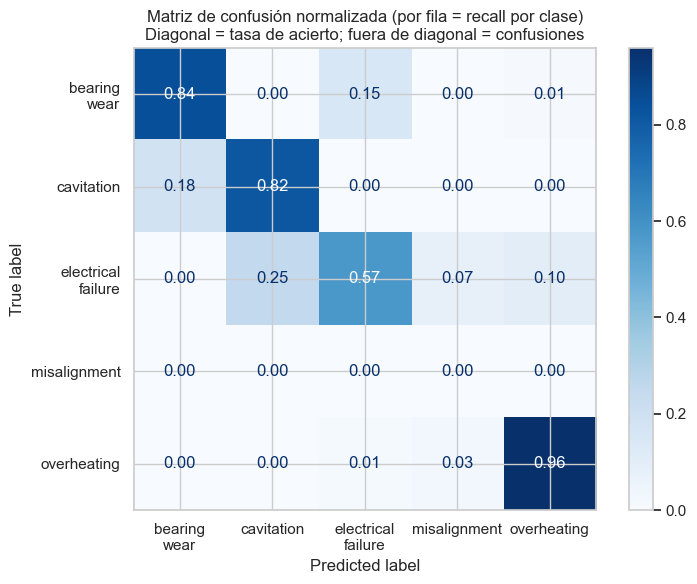

Lectura: fila=real, col=predicho. Valor(i,j) = P(pred=j | real=i)
Ejemplo: fila misalignment, col bearing_wear → % de misalignment predicho como bearing_wear


In [54]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=[c.replace('_', '\n') for c in CLASSES],
)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
ax.set_title(
    'Matriz de confusión normalizada (por fila = recall por clase)\n'
    'Diagonal = tasa de acierto; fuera de diagonal = confusiones'
)
plt.tight_layout()
plt.show()

print('Lectura: fila=real, col=predicho. Valor(i,j) = P(pred=j | real=i)')
print('Ejemplo: fila misalignment, col bearing_wear → % de misalignment predicho como bearing_wear')

In [55]:
report_str  = classification_report(y_test, y_pred, target_names=CLASSES)
report_dict = classification_report(y_test, y_pred, target_names=CLASSES, output_dict=True)

print(report_str)

macro_f1    = report_dict['macro avg']['f1-score']
weighted_f1 = report_dict['weighted avg']['f1-score']

print(f'Macro F1:    {macro_f1:.4f}  ← métrica principal')
print(f'Weighted F1: {weighted_f1:.4f}')
print()
print('Nota: macro F1 pondera igual todas las clases.')
print('      weighted F1 pondera por el tamaño de la clase (más influencia de bearing_wear).')

                    precision    recall  f1-score   support

      bearing_wear       0.92      0.84      0.88       212
        cavitation       0.88      0.82      0.85        87
electrical_failure       0.42      0.57      0.48        40
      misalignment       0.00      0.00      0.00         0
       overheating       0.92      0.96      0.94        74

          accuracy                           0.83       413
         macro avg       0.63      0.64      0.63       413
      weighted avg       0.86      0.83      0.84       413

Macro F1:    0.6299  ← métrica principal
Weighted F1: 0.8450

Nota: macro F1 pondera igual todas las clases.
      weighted F1 pondera por el tamaño de la clase (más influencia de bearing_wear).


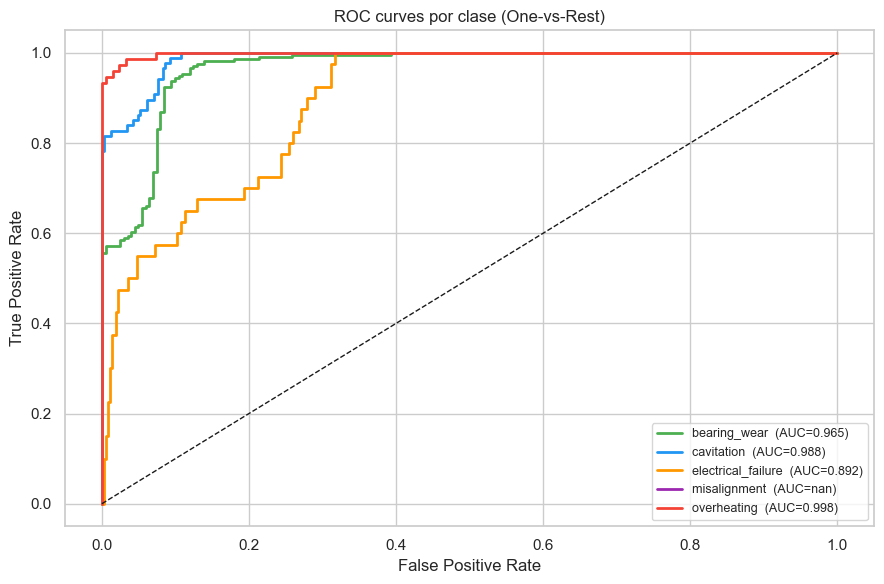

Macro ROC-AUC (OVR): nan

AUC > 0.90 por clase = buena discriminación binaria.
Clases con AUC bajo necesitan más datos o features más específicas.


In [56]:
# ROC curves — One-vs-Rest por clase
y_test_bin = label_binarize(y_test, classes=list(range(len(CLASSES))))

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336']

for i, (cls, color) in enumerate(zip(CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_cls = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls}  (AUC={roc_auc_cls:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves por clase (One-vs-Rest)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

macro_roc = roc_auc_score(y_test_bin, y_prob, average='macro')
print(f'Macro ROC-AUC (OVR): {macro_roc:.4f}')
print('\nAUC > 0.90 por clase = buena discriminación binaria.')
print('Clases con AUC bajo necesitan más datos o features más específicas.')

---
## Paso 7: Importancia de features

XGBoost calcula importancia por **gain** (reducción de impureza acumulada en todos los
splits usando esa feature). No es lo mismo que causalidad — es qué tanto usó el modelo
esa feature para discriminar.

**Qué esperamos ver**:
- Features de temperatura arriba (discriminan overheating)
- `current_imbalance` alta (discrimina electrical_failure)
- `machine_type_enc` importante (cavitation solo en pumps)
- Features de tendencia (slope) más útiles que el valor raw instantáneo

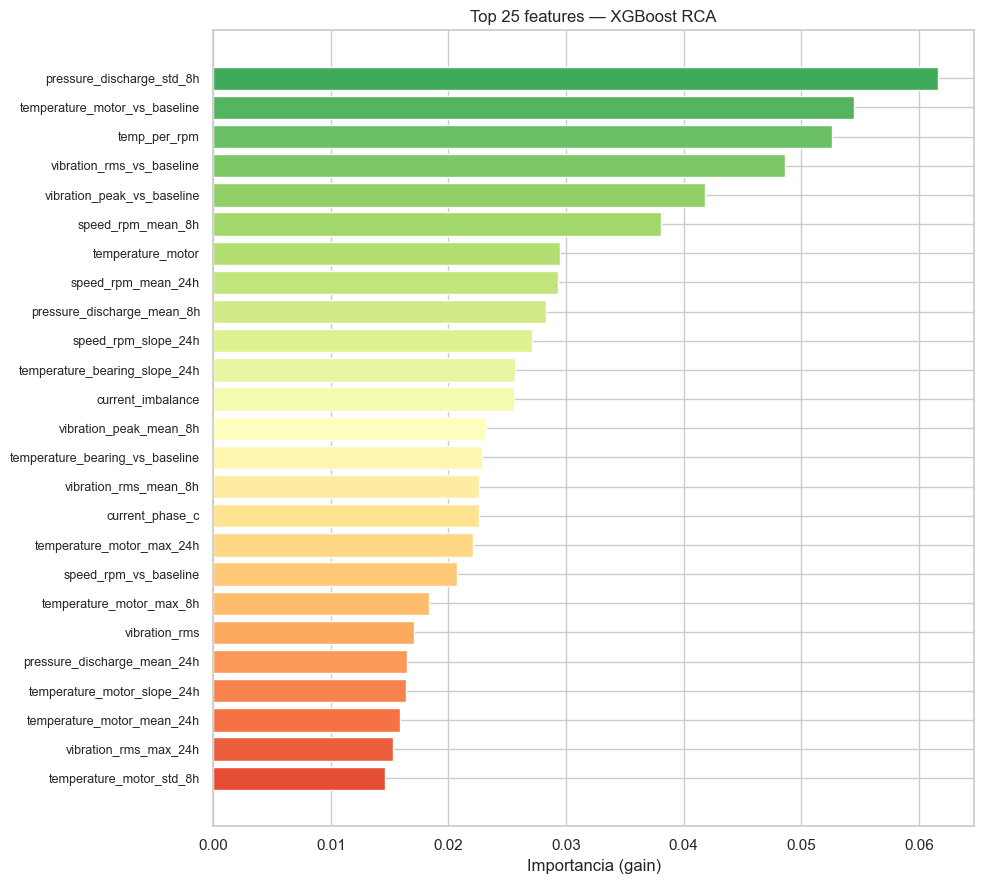

Top 10:
pressure_discharge_std_8h        0.0616
temperature_motor_vs_baseline    0.0545
temp_per_rpm                     0.0526
vibration_rms_vs_baseline        0.0486
vibration_peak_vs_baseline       0.0418
speed_rpm_mean_8h                0.0381
temperature_motor                0.0295
speed_rpm_mean_24h               0.0293
pressure_discharge_mean_8h       0.0283
speed_rpm_slope_24h              0.0271


In [57]:
importances = (
    pd.Series(model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)

top_n = 25
top = importances.head(top_n)

fig, ax = plt.subplots(figsize=(10, 9))
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, top_n))
ax.barh(range(top_n), top.values, color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Importancia (gain)')
ax.set_title(f'Top {top_n} features — XGBoost RCA')
plt.tight_layout()
plt.show()

print('Top 10:')
print(importances.head(10).round(4).to_string())

---
## Paso 8: Registrar en MLflow

Se guarda:
- Todos los hiperparámetros
- Métricas por clase (precision/recall/F1) + macro/weighted F1 + macro ROC-AUC
- Artefactos de inferencia: `rca_class_map.json`, `rca_feature_cols.json`
- El modelo XGBoost en el Model Registry como `amia-rca-model`

**¿Por qué el class_map como artefacto?** En tiempo real necesitamos invertir el índice
(0 → 'bearing_wear') sin saber qué orden usó el notebook al entrenar.

---
## Benchmark: XGBoost vs LightGBM

LightGBM es el competidor más directo de XGBoost en datos tabulares.

### Diferencias arquitectónicas clave
| | XGBoost | LightGBM |
|---|---|---|
| Estrategia de split | **Level-wise** (por nivel del árbol) | **Leaf-wise** (el hoja con mayor ganancia) |
| `class_weight` multiclase | ❌ (necesitas `sample_weight` manual) | ✅ nativo |
| Velocidad en dataset mediano | Buena | **Mejor** |
| `num_leaves` | controlado por `max_depth` | configurable independientemente |

**Leaf-wise** puede capturar patrones más complejos con menos árboles,
pero es más propenso a overfitting — se controla con `min_child_samples`.

Usamos la misma arquitectura de features y el mismo split temporal para comparar justamente.

In [58]:
try:
    import lightgbm as lgb
    print(f'LightGBM version: {lgb.__version__}')
except ImportError:
    print('LightGBM no instalado. Ejecutar: uv add lightgbm')
    raise

LightGBM version: 4.6.0


In [59]:
# LightGBM tiene class_weight='balanced' nativo — sin sample_weight manual
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=4,
    num_leaves=31,          # leaf-wise: 2^max_depth-1 es el tope recomendado
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_samples=10,   # mínimo de muestras en cada hoja (regularización)
    reg_lambda=2.0,
    reg_alpha=0.5,
    objective='multiclass',
    num_class=len(CLASSES),
    class_weight='balanced', # ← nativo, equivalente a nuestro sample_weight
    metric='multi_logloss',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(30, verbose=False),
        lgb.log_evaluation(50),
    ],
)

print(f'\nMejor iteración LightGBM: {lgb_model.best_iteration_}')
print(f'Mejor mlogloss LightGBM:  {lgb_model.best_score_["valid_0"]["multi_logloss"]:.4f}')
print(f'Mejor mlogloss XGBoost:   {model.best_score:.4f}  (referencia)')

[50]	valid_0's multi_logloss: 0.544174
[100]	valid_0's multi_logloss: 0.490584

Mejor iteración LightGBM: 108
Mejor mlogloss LightGBM:  0.4874
Mejor mlogloss XGBoost:   0.4461  (referencia)


### Comparación de métricas: XGBoost vs LightGBM

Evaluamos ambos modelos con las mismas métricas sobre el mismo test set.
No hay un ganador universal — el modelo que elijas para producción
depende de qué clases son más importantes para el negocio.

In [60]:
lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)

y_test_bin = label_binarize(y_test, classes=list(range(len(CLASSES))))

def compute_metrics(y_true, y_pred, y_prob, model_name):
    rd   = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True)
    yb   = label_binarize(y_true, classes=list(range(len(CLASSES))))
    mroc = roc_auc_score(yb, y_prob, average='macro')
    row  = {'Modelo': model_name,
            'Macro F1': round(rd['macro avg']['f1-score'], 4),
            'Weighted F1': round(rd['weighted avg']['f1-score'], 4),
            'Macro ROC-AUC': round(mroc, 4)}
    for cls in CLASSES:
        row[f'F1 {cls[:6]}'] = round(rd[cls]['f1-score'], 3)
    return row

rows = [
    compute_metrics(y_test, y_pred,  y_prob,   'XGBoost'),
    compute_metrics(y_test, lgb_pred, lgb_prob, 'LightGBM'),
]

df_comp = pd.DataFrame(rows).set_index('Modelo')

print('=== Comparación global ===')
print(df_comp[['Macro F1', 'Weighted F1', 'Macro ROC-AUC']].to_string())
print()
print('=== F1 por clase ===')
f1_cols = [c for c in df_comp.columns if c.startswith('F1')]
print(df_comp[f1_cols].to_string())

=== Comparación global ===
          Macro F1  Weighted F1  Macro ROC-AUC
Modelo                                        
XGBoost     0.6299       0.8450            NaN
LightGBM    0.6291       0.8402            NaN

=== F1 por clase ===
          F1 bearin  F1 cavita  F1 electr  F1 misali  F1 overhe
Modelo                                                         
XGBoost       0.880      0.845      0.484        0.0       0.94
LightGBM      0.873      0.833      0.500        0.0       0.94


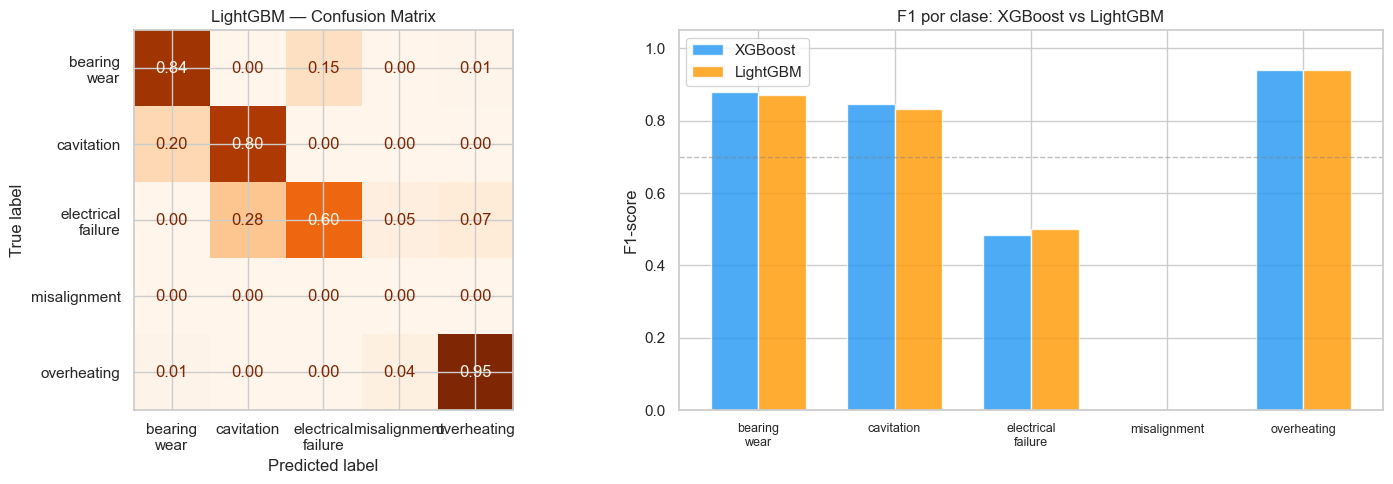


→ Ganador por Macro F1: XGBoost  (0.6299 vs 0.6291)
  Para train_rca.py usaremos el ganador.


In [61]:
# Visualización: F1 por clase side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix LightGBM
cm_lgb = confusion_matrix(y_test, lgb_pred, normalize='true')
ConfusionMatrixDisplay(
    confusion_matrix=cm_lgb,
    display_labels=[c.replace('_', '\n') for c in CLASSES],
).plot(ax=axes[0], colorbar=False, cmap='Oranges', values_format='.2f')
axes[0].set_title('LightGBM — Confusion Matrix')

# Bar chart F1 por clase
ax = axes[1]
x = np.arange(len(CLASSES))
w = 0.35
xgb_f1s = [classification_report(y_test, y_pred,   target_names=CLASSES, output_dict=True)[c]['f1-score'] for c in CLASSES]
lgb_f1s = [classification_report(y_test, lgb_pred, target_names=CLASSES, output_dict=True)[c]['f1-score'] for c in CLASSES]
ax.bar(x - w/2, xgb_f1s, w, label='XGBoost',  color='#2196F3', alpha=0.8)
ax.bar(x + w/2, lgb_f1s, w, label='LightGBM', color='#FF9800', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in CLASSES], fontsize=9)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.05)
ax.set_title('F1 por clase: XGBoost vs LightGBM')
ax.legend()
ax.axhline(0.7, color='gray', ls='--', lw=1, alpha=0.5)

plt.tight_layout()
plt.show()

# Elección final
xgb_macro = df_comp.loc['XGBoost',   'Macro F1']
lgb_macro = df_comp.loc['LightGBM',  'Macro F1']
winner = 'LightGBM' if lgb_macro >= xgb_macro else 'XGBoost'
print(f'\n→ Ganador por Macro F1: {winner}  ({max(xgb_macro, lgb_macro):.4f} vs {min(xgb_macro, lgb_macro):.4f})')
print('  Para train_rca.py usaremos el ganador.')

In [62]:
# ── Diagnóstico pre-MLflow ───────────────────────────────────────────────
# Verifica que todas las variables necesarias existen y no son NaN.
# Si algo falla aquí, vuelve a ejecutar las celdas de evaluación primero.

import math


def is_nan(v):
    try:
        return math.isnan(float(v))
    except Exception:
        return True

# Recomputar macro_roc con manejo de clases faltantes en test
# roc_auc_score falla con NaN si alguna clase no tiene muestras en y_test
y_test_bin_check = label_binarize(y_test, classes=list(range(len(CLASSES))))

per_class_roc = []
missing_classes = []
for i, cls in enumerate(CLASSES):
    n_pos = y_test_bin_check[:, i].sum()
    if n_pos == 0:
        missing_classes.append(cls)
        per_class_roc.append(0.0)
        print(f'  ⚠️  {cls}: 0 muestras positivas en test → AUC forzado a 0.0')
    else:
        from sklearn.metrics import roc_auc_score as ras
        auc_val = ras(y_test_bin_check[:, i], y_prob[:, i])
        per_class_roc.append(auc_val)

macro_roc = float(sum(per_class_roc) / len(per_class_roc))

if missing_classes:
    print(f'\n  Clases sin muestras en test: {missing_classes}')
    print('  Esto ocurre con split temporal estricto y clases raras.')
    print(f'  macro_roc recalculado: {macro_roc:.4f} (forzando AUC=0 en clases faltantes)')
else:
    print('  ✓ Todas las clases tienen muestras en test')
    print(f'  macro_roc: {macro_roc:.4f}')

# Verificar otras métricas
checks = {'macro_f1': macro_f1, 'weighted_f1': weighted_f1, 'macro_roc': macro_roc}
print()
for name, val in checks.items():
    status = '❌ NaN' if is_nan(val) else f'✓ {float(val):.4f}'
    print(f'  {name:<15} {status}')

nan_count = sum(1 for v in checks.values() if is_nan(v))
if nan_count == 0:
    print('\n✓ Todas las métricas son válidas. Puedes ejecutar la celda MLflow.')
else:
    print(f'\n⚠️  {nan_count} métricas son NaN — se loguearán como 0.0 en MLflow.')

  ⚠️  misalignment: 0 muestras positivas en test → AUC forzado a 0.0

  Clases sin muestras en test: ['misalignment']
  Esto ocurre con split temporal estricto y clases raras.
  macro_roc recalculado: 0.7685 (forzando AUC=0 en clases faltantes)

  macro_f1        ✓ 0.6299
  weighted_f1     ✓ 0.8450
  macro_roc       ✓ 0.7685

✓ Todas las métricas son válidas. Puedes ejecutar la celda MLflow.


In [63]:
# mlflow.end_run() cierra cualquier run activo antes de empezar uno nuevo.
mlflow.end_run()

EXPERIMENT_NAME = 'amia-rca'
MODEL_NAME      = 'amia-rca-model'

def safe_metric(v):
    """Convierte NaN/Inf → 0.0. MLflow/SQLite falla con is_nan=1 en algunas versiones."""
    try:
        f = float(v)
        return 0.0 if (f != f or abs(f) == float('inf')) else f
    except Exception:
        return 0.0

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run() as run:
    # ── Hiperparámetros ───────────────────────────────────────────────────
    mlflow.log_params({k: v for k, v in HPARAMS.items()})
    mlflow.log_params({
        'n_features':      len(feature_cols),
        'n_classes':       len(CLASSES),
        'train_rows':      len(X_train),
        'test_rows':       len(X_test),
        'split_date':      str(SPLIT_DATE),
        'class_weighting': 'balanced',
    })

    # ── Métricas (safe_metric guarda contra NaN → IntegrityError SQLite) ──
    mlflow.log_metric('macro_f1',       safe_metric(macro_f1))
    mlflow.log_metric('weighted_f1',    safe_metric(weighted_f1))
    mlflow.log_metric('macro_roc_auc',  safe_metric(macro_roc))
    mlflow.log_metric('best_iteration', model.best_iteration)
    mlflow.log_metric('best_mlogloss',  model.best_score)
    for cls in CLASSES:
        mlflow.log_metric(f'f1_{cls}',        safe_metric(report_dict[cls]['f1-score']))
        mlflow.log_metric(f'precision_{cls}',  safe_metric(report_dict[cls]['precision']))
        mlflow.log_metric(f'recall_{cls}',     safe_metric(report_dict[cls]['recall']))

    # ── Artefactos de inferencia ──────────────────────────────────────────
    import os
    import tempfile
    tmp = tempfile.mkdtemp()

    class_map_path = os.path.join(tmp, 'rca_class_map.json')
    with open(class_map_path, 'w') as f:
        json.dump(CLASS_MAP, f, indent=2)
    mlflow.log_artifact(class_map_path, artifact_path='inference')

    feature_cols_path = os.path.join(tmp, 'rca_feature_cols.json')
    with open(feature_cols_path, 'w') as f:
        json.dump(list(feature_cols), f, indent=2)
    mlflow.log_artifact(feature_cols_path, artifact_path='inference')

    fi_path = os.path.join(tmp, 'rca_feature_importances.csv')
    importances.to_csv(fi_path, header=True)
    mlflow.log_artifact(fi_path)

    # ── Registrar modelo ─────────────────────────────────────────────────
    mlflow.xgboost.log_model(
        model,
        name='model',
        registered_model_name=MODEL_NAME,
        input_example=X_train.head(5),
    )

    print(f'Run ID:      {run.info.run_id}')
    print(f'Experimento: {EXPERIMENT_NAME}')
    print(f'Modelo:      {MODEL_NAME}')
    print(f'\nMacro F1:       {safe_metric(macro_f1):.4f}')
    print(f'Weighted F1:    {safe_metric(weighted_f1):.4f}')
    print(f'Macro ROC-AUC:  {safe_metric(macro_roc):.4f}')

2026/06/25 15:57:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/06/25 15:57:41 INFO mlflow.models.model: Found the following environment variables used during model inference: [ANTHROPIC_API_KEY, OPENAI_API_KEY]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.


Run ID:      4f6e042c16e748f2b6bd5a207ce917f8
Experimento: amia-rca
Modelo:      amia-rca-model

Macro F1:       0.6299
Weighted F1:    0.8450
Macro ROC-AUC:  0.7685


Successfully registered model 'amia-rca-model'.
Created version '1' of model 'amia-rca-model'.


---
## Paso 9: ¿Cómo se usará en producción?

En V3, el flujo será:
```
sensor_reading → FailurePredictor → prob > threshold
                                         ↓
                                    RCAPredictor
                                         ↓
                              {failure_mode, confidence, probabilities}
                                         ↓
                                 sensor_analyst agent
                                         ↓
                           EconomicImpact → WorkOrder
```

La inferencia RCA necesita exactamente las mismas features que entrenamiento —
por eso guardamos `rca_feature_cols.json` en MLflow.

El `RCAPredictor` reutilizará el **mismo buffer circular de V2** (`deque` de 50
lecturas) para calcular los rolling features en tiempo real.

In [64]:
# Preview de la API de inferencia — esto se implementa en
# backend/app/services/rca_predictor.py en el siguiente paso

def predict_root_cause_preview(
    buffer_df: pd.DataFrame,
    threshold: float = 0.4,
) -> dict:
    """
    buffer_df: DataFrame con ≥ 24 filas de una máquina (mismo schema que sensor_readings)
    threshold: si la probabilidad de la clase ganadora < threshold, devuelve 'uncertain'
    """
    # Feature engineering sobre el buffer
    df_f = add_rolling_stats(buffer_df.copy())
    df_f = add_trend_features(df_f)
    df_f = add_delta_features(df_f)
    df_f = add_cross_sensor_features(df_f)
    df_f = add_baseline_normalization(df_f)
    df_f['machine_type_enc'] = df_f['machine_type'].map(MACHINE_TYPE_MAP).fillna(0)

    # Última fila = instante actual
    row = df_f.iloc[[-1]].copy()

    # Alinear columnas con el modelo
    for c in feature_cols:
        if c not in row.columns:
            row[c] = 0.0
    X = row[feature_cols]

    proba = model.predict_proba(X)[0]  # shape (5,)
    best_idx  = int(np.argmax(proba))
    best_prob = float(proba[best_idx])
    best_cls  = INV_CLASS_MAP[best_idx]

    return {
        'failure_mode':  best_cls if best_prob >= threshold else 'uncertain',
        'confidence':    best_prob,
        'probabilities': {INV_CLASS_MAP[i]: float(p) for i, p in enumerate(proba)},
    }


print('Función de inferencia definida.')
print('Requiere buffer de ≥ 24 lecturas para rolling features de 24h.')
print()
print('Próximo paso: implementar RCAPredictor en backend/app/services/rca_predictor.py')
print('  → carga modelo desde MLflow al arrancar')
print('  → reutiliza el buffer circular de FailurePredictor')
print('  → expone predict_rca(machine_id) → dict')

Función de inferencia definida.
Requiere buffer de ≥ 24 lecturas para rolling features de 24h.

Próximo paso: implementar RCAPredictor en backend/app/services/rca_predictor.py
  → carga modelo desde MLflow al arrancar
  → reutiliza el buffer circular de FailurePredictor
  → expone predict_rca(machine_id) → dict


---
## Resumen y próximos pasos

### Lo que construimos
- Clasificador multiclase XGBoost con `multi:softprob` sobre 5 modos de fallo
- Pipeline de feature engineering reutilizado de V2 (rolling stats, trends, deltas, cross-sensor)
- Balanceo con `sample_weight` balanceado (ratio máx/mín ≈ 9x)
- Registrado en MLflow como `amia-rca-model` con artefactos de inferencia

### Decisiones clave 
| Decisión | Alternativa descartada | Por qué la tomamos |
|---|---|---|
| Entrenar solo en degradation rows | Entrenar en todos los datos | RCA se invoca post-alerta; incluir normal diluye la señal |
| `sample_weight` balanceado | Sin balanceo | Ratio 9:1 → el modelo ignoraría electrical_failure |
| `multi:softprob` | `softmax` | Necesitamos probabilidades para explicabilidad del agente |
| Split temporal | Split aleatorio | Simula producción; evita leakage de misma máquina en train+test |
| Mismas features que V2 | Features nuevas | Los patrones de degradación ya están ahí; no re-inventar |

